4200
700
700
tensor(0.0029) tensor(0.0060)
<class 'torchvision.tv_tensors._image.Image'>
<class 'torchvision.tv_tensors._image.Image'>


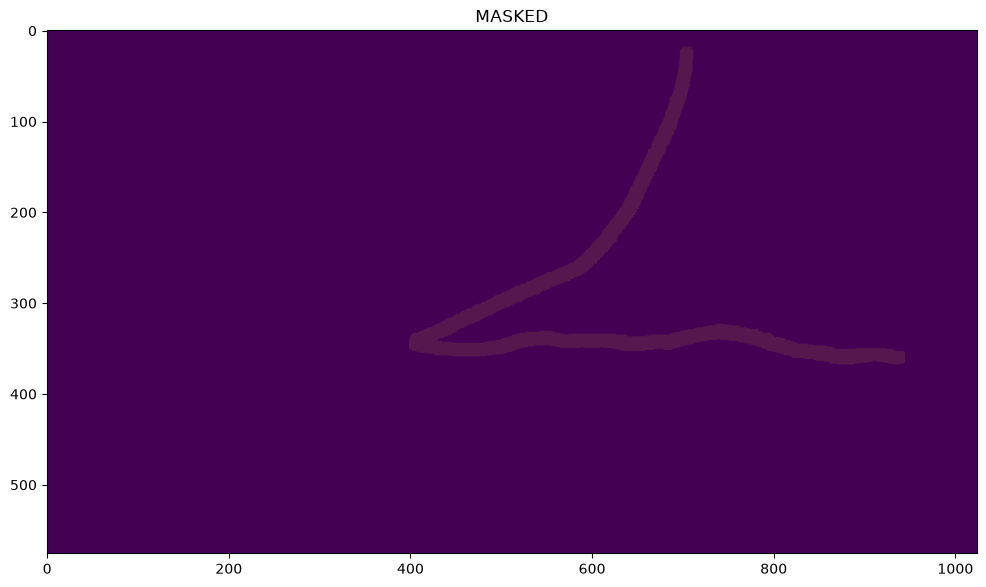

epoch 1 / 10
train loss = 0.05559604775288519
vali loss = 0.0008339550708712058
epoch 2 / 10
train loss = 0.002956715629272561
vali loss = 0.000335264214286083
epoch 3 / 10
train loss = 0.0016941284007243528
vali loss = 0.002488764230417841
epoch 4 / 10
train loss = 0.0006432788937978219
vali loss = 7.920775838900102e-05
epoch 5 / 10
train loss = 0.00040588801449434905
vali loss = 5.635399118559932e-05
epoch 6 / 10
train loss = 0.0003183411712223266
vali loss = 4.664551987017697e-05
epoch 7 / 10
train loss = 0.0002737438778538712
vali loss = 4.33810279644201e-05
epoch 8 / 10
train loss = 0.0002456159829224268
vali loss = 3.651167752171461e-05
epoch 9 / 10
train loss = 0.00022500803923404967
vali loss = 3.713020734499628e-05
epoch 10 / 10
train loss = 0.00021041503050791115
vali loss = 3.4419781611059285e-05


In [1]:
import cygnet, torch, os
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision.ops import sigmoid_focal_loss

# paths
train_path = "/home/frx/dataset/image_dataset/train"
vali_path = "/home/frx/dataset/image_dataset/vali"
test_path = "/home/frx/dataset/image_dataset/test"

# folders:
input_path = "input"
mask_path = "mask"
mask_exp2_path = "mask_exp2"
mask_exp4_path = "mask_exp4"

# change this
target_path = mask_exp4_path

input_train_path = os.path.join(train_path, input_path)
target_train_path = os.path.join(train_path, target_path)

input_vali_path = os.path.join(vali_path, input_path)
target_vali_path = os.path.join(vali_path, target_path)

input_test_path = os.path.join(test_path, input_path)
target_test_path = os.path.join(test_path, target_path)

train_dset = cygnet.CygnoSet(input_train_path, target_train_path)
print(len(train_dset))
vali_dset = cygnet.CygnoSet(input_vali_path, target_vali_path)
print(len(vali_dset))
test_dset = cygnet.CygnoSet(input_test_path, target_test_path)
print(len(test_dset))

image, mask = train_dset[1]

print(image.min(), image.max())
print(type(mask))
print(type(image))

cygnet.debug_plot(image.cpu().squeeze(), mask.cpu().squeeze())

train_dloader = DataLoader(train_dset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)
vali_dloader = DataLoader(vali_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
test_dloader = DataLoader(test_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

net = cygnet.Net(4).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.StepLR(opt, 10, gamma=0.1, last_epoch=-1)

num_epochs = 10
train_loss_history = []
vali_loss_history = []

for epoch in range(num_epochs):
	print(f"epoch {epoch+1} / {num_epochs}")
	
	net.train()
	train_loss = 0
	c = 0
	for imgs, masks in train_dloader:
		c += 1
		imgs  = imgs.to(device, non_blocking=True)
		masks = masks.to(device, non_blocking=True)
		opt.zero_grad(set_to_none=True)
		
		preds = net(imgs)

		loss = sigmoid_focal_loss(preds, masks, reduction="mean")
		loss.backward()
		opt.step()
		train_loss += loss.item()
	
	train_loss /= c
	train_loss_history.append(train_loss)
	print(f"train loss = {train_loss}")
	
	net.eval()
	vali_loss = 0
	with torch.inference_mode():
		for imgs, masks in vali_dloader:
			imgs  = imgs.to(device, non_blocking=True)
			masks = masks.to(device, non_blocking=True)

			preds = net(imgs)

			vloss = sigmoid_focal_loss(preds, masks, reduction="mean")
			vali_loss += vloss.item()
		vali_loss /= c
		vali_loss_history.append(vali_loss)
		print(f"vali loss = {vali_loss}")
	
	scheduler.step()

[0.05559604775288519, 0.002956715629272561, 0.0016941284007243528, 0.0006432788937978219, 0.00040588801449434905, 0.0003183411712223266, 0.0002737438778538712, 0.0002456159829224268, 0.00022500803923404967, 0.00021041503050791115]


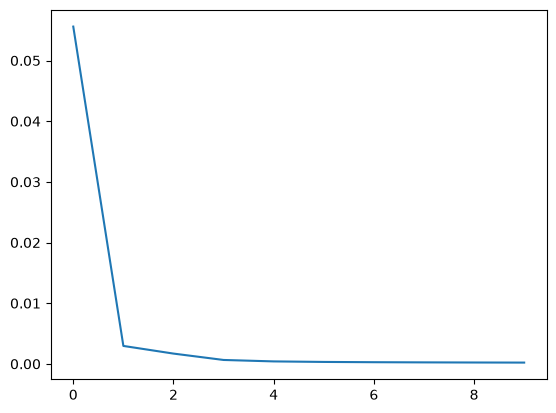

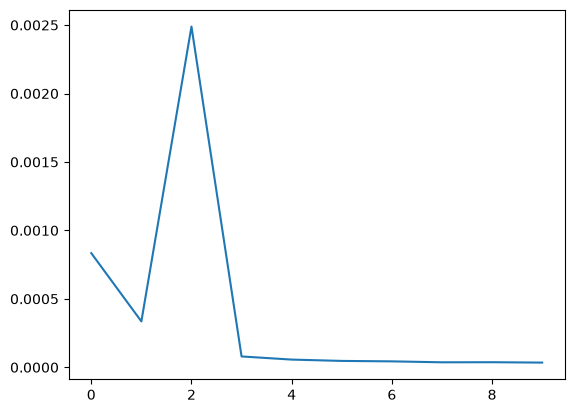

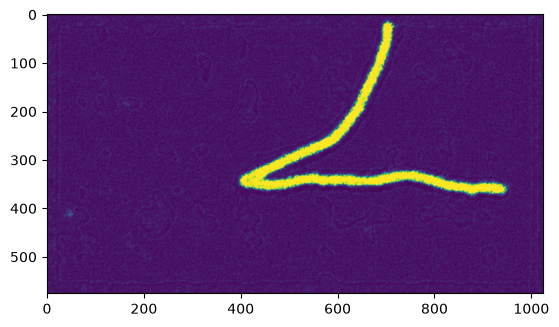

tensor(0.5000, device='cuda:0') tensor(0.0082, device='cuda:0')


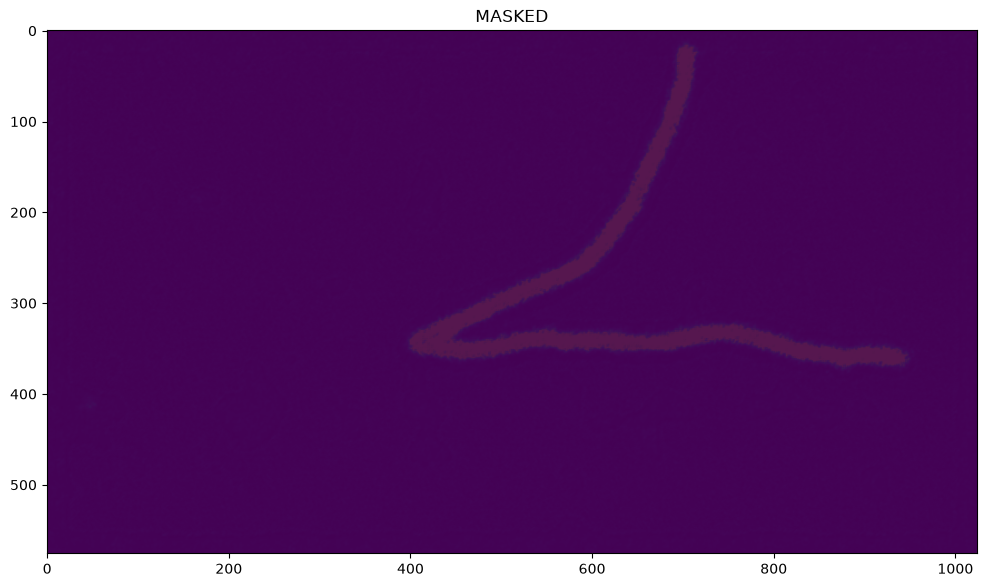

In [2]:
xt = [x for x in range(len(train_loss_history))]
xv = [x for x in range(len(vali_loss_history))]

print(train_loss_history)

net.eval()

plt.figure()
plt.plot(xt, train_loss_history)
plt.show()

plt.figure()
plt.plot(xv, vali_loss_history)
plt.show()
net.eval()

with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
pred = torch.sigmoid(pred)

plt.figure()
plt.imshow(pred.cpu().squeeze())
plt.show()

print(pred.max(), pred.min())
cygnet.debug_plot(image.cpu().squeeze(), pred.cpu().squeeze())

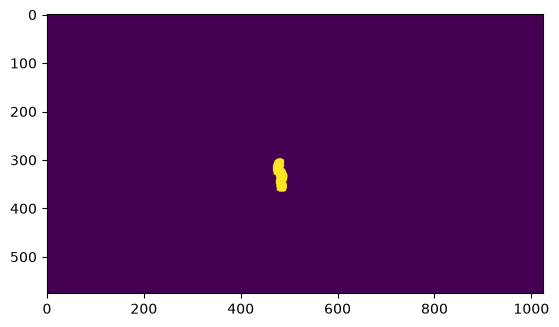

tensor(0., device='cuda:0') tensor(-4.8226, device='cuda:0')


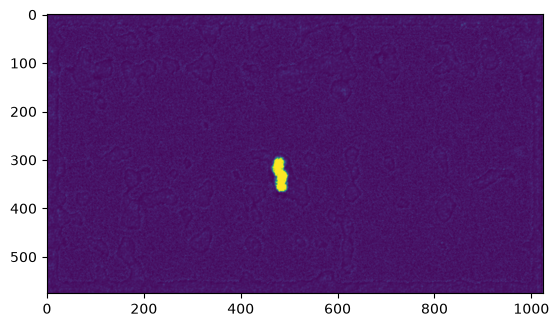

0.42238649725914


In [7]:
image, mask = test_dset[123]

net.eval()
plt.figure()
plt.imshow(mask.cpu().squeeze())
plt.show()
with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
spred = torch.sigmoid(pred)
print(pred.max(), pred.min())
sspred = (pred > 0).float()
plt.figure()
plt.imshow(spred.cpu().squeeze())
plt.show()

print(sigmoid_focal_loss(mask.cpu().squeeze(), pred.cpu().squeeze(), reduction="mean").item())

In [8]:
torch.save({'model' : net,
	'epoch': epoch+1,
	'model_state_dict': net.state_dict(),
	'optimizer_state_dict': opt.state_dict(),
	'loss': sigmoid_focal_loss,
	}, 'best_model.pt')